# Aerogel Filtration ML --> Step 2: Preprocessing

**What this notebook does:**
- Drops collinear and invalid columns
- Log-transforms skewed targets and features
- Encodes categorical variables
- Builds two clean model-ready dataframes (one per target)
- Saves them to CSV for use in Step 3

## 2.1: Imports and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


DATA_PATH = 'final_dataset.csv'


df = pd.read_csv(DATA_PATH)

# dropping completely empty rows (trailing Excel rows)
df.dropna(how='all', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Loaded: {df.shape[0]} samples, {df.shape[1]} columns')

Loaded: 227 samples, 41 columns


## 2.2: Drop columns we decided to exclude

In [15]:
# bulk_density is dropped because it is collinear with porosity (r = -0.93).
# Keeping both would give the model redundant information and inflate
# the apparent importance of one of them.
#
# we also drop identifier/text columns that carry no numeric signal.

COLS_TO_DROP = [
    'material_class_original',
    'chemical_composition_original',
    'material_name',
    'source',
    'bulk_density (g/cm3)', # collinear with porosity r = -0.935; dropped here
]

# Only drop columns that actually exist in the dataframe
cols_to_drop_existing = [c for c in COLS_TO_DROP if c in df.columns]
df.drop(columns=cols_to_drop_existing, inplace=True)

print('Dropped:', cols_to_drop_existing)
print(f'Remaining columns: {df.shape[1]}')

Dropped: []
Remaining columns: 46


## 2.4: Log-transform skewed features

In [16]:
# Several numeric features span multiple orders of magnitude.
# Without log-transformation, the model is dominated by extreme values.
#
# Rule: apply log1p (= log(x + 1)) to any feature with skewness > 1.5
# log1p handles zero values safely (log(0+1) = 0)
#
# permeability specifically: spans 4 orders of magnitude, must be log-transformed

# Define which numeric features to check
NUMERIC_FEATURES = [
    'solid_content (g/100ml)',
    'skeletal_density (g/cm3)',
    'porosity (%)',
    'permeability (m2)',
    'bet_surface_area (m2/g)',
    'average_pore_size (nm)',
    'fiber_diameter (nm)',
    'airflow_rate (cm/s)',
    'sample_thickness (mm)',
    'average_particle_size (nm)',
]
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df.columns]

print(f'{"Column":<35} {"Skewness":>10} {"Action"}')
print('-' * 65)

LOG_TRANSFORMED = []  # keeping track of which columns were transformed

for col in NUMERIC_FEATURES:
    data = df[col].dropna()
    if len(data) < 5:
        continue
    skew = data.skew()
    
    # Force log-transform permeability (physical justification: spans 4 orders)
    force_log = col == 'permeability (m2)'
    
    if abs(skew) > 1.5 or force_log:
        # Check all values are non-negative before log-transforming
        if data.min() >= 0:
            new_col = f'log_{col}'
            df[new_col] = np.log1p(df[col])  # log(x + 1), safe for zeros
            LOG_TRANSFORMED.append((col, new_col))
            print(f'{col:<35} {skew:>10.3f}   → log-transformed as {new_col}')
        else:
            print(f'{col:<35} {skew:>10.3f}   ⚠ has negative values, skipping log')
    else:
        print(f'{col:<35} {skew:>10.3f}   ✓ no transform needed')

print(f'\n{len(LOG_TRANSFORMED)} features log-transformed.')

Column                                Skewness Action
-----------------------------------------------------------------
solid_content (g/100ml)                  1.159   ✓ no transform needed
skeletal_density (g/cm3)                 1.935   → log-transformed as log_skeletal_density (g/cm3)
porosity (%)                            -1.903   → log-transformed as log_porosity (%)
permeability (m2)                        0.000   → log-transformed as log_permeability (m2)
bet_surface_area (m2/g)                  0.991   ✓ no transform needed
average_pore_size (nm)                   3.159   → log-transformed as log_average_pore_size (nm)
fiber_diameter (nm)                      4.213   → log-transformed as log_fiber_diameter (nm)
airflow_rate (cm/s)                      2.382   → log-transformed as log_airflow_rate (cm/s)
sample_thickness (mm)                    2.058   → log-transformed as log_sample_thickness (mm)
average_particle_size (nm)               3.613   → log-transformed as log_avera

## 2.5: Transform target variables

In [17]:
# From EDAstep:
#   filtration_efficiency skewness = -2.927  → use log(100 - efficiency)
#   quality_factor skewness        = +6.445  → use log(QF + 1)

TARGET_EFF = 'filtration_efficiency (%)'
TARGET_QF  = 'quality_factor (mmH2O^-1)'

# Filtration efficiency transform
if TARGET_EFF in df.columns:
    # Handle edge case: if efficiency = 100 exactly, then --> log(0) = -inf
    # Cap at 99.999 before transforming
    eff_capped = df[TARGET_EFF].clip(upper=99.999)
    df['log_penetration'] = np.log(100 - eff_capped)  # log(100 - η)

    print('log_penetration = log(100 - filtration_efficiency)')
    print('(lower value = better filter, i.e. less particle penetration)')
    print(df['log_penetration'].describe().round(3))
    print(f'Skewness after transform: {df["log_penetration"].skew():.3f}')
    print()

# Quality factor transform
if TARGET_QF in df.columns:
    df['log_quality_factor'] = np.log1p(df[TARGET_QF])  # log(QF + 1)
    print('log_quality_factor = log(quality_factor + 1)')
    print(df['log_quality_factor'].describe().round(3))
    print(f'Skewness after transform: {df["log_quality_factor"].skew():.3f}')

log_penetration = log(100 - filtration_efficiency)
(lower value = better filter, i.e. less particle penetration)
count    195.000
mean      -0.327
std        3.258
min       -6.908
25%       -2.303
50%        0.105
75%        2.197
max        4.605
Name: log_penetration, dtype: float64
Skewness after transform: -0.595

log_quality_factor = log(quality_factor + 1)
count    82.000
mean      0.615
std       0.930
min       0.000
25%       0.214
50%       0.303
75%       0.591
max       5.249
Name: log_quality_factor, dtype: float64
Skewness after transform: 3.565


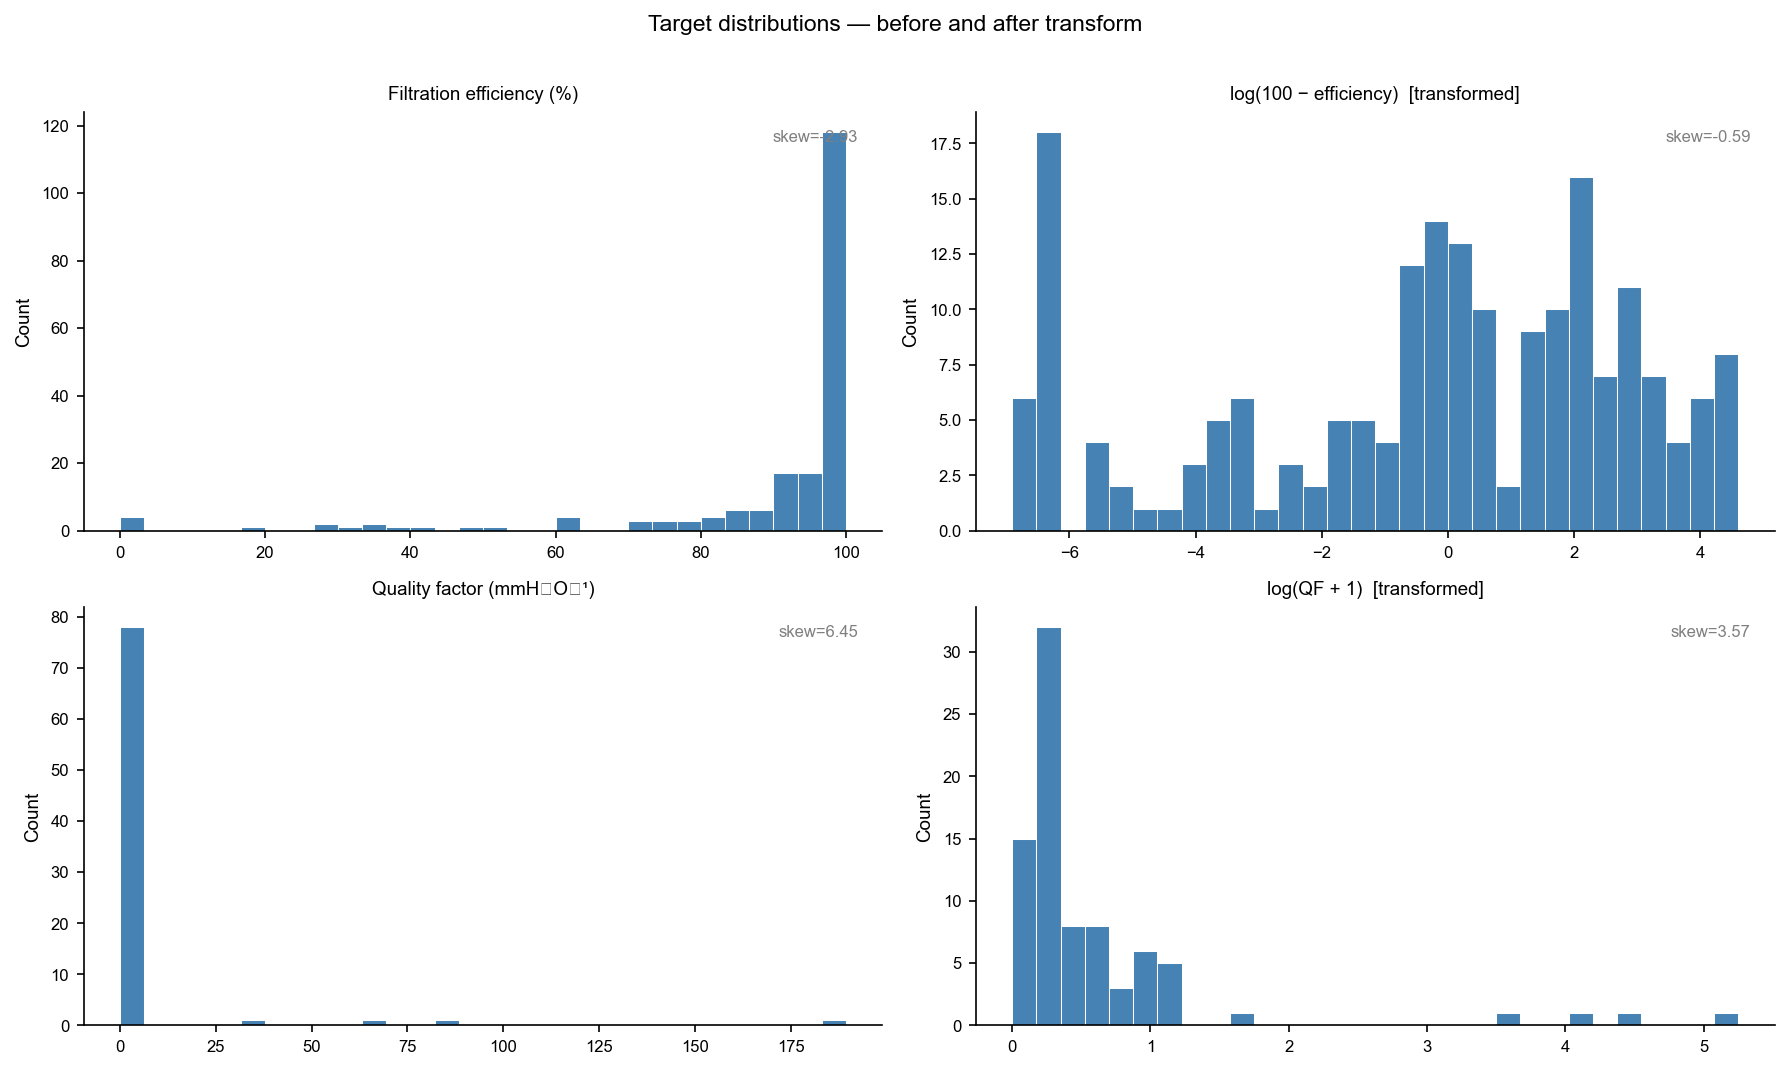

Saved: target_transform_comparison.png


In [18]:
# Visual check: compare before/after distributions for both targets
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

pairs = [
    (TARGET_EFF,           'Filtration efficiency (%)',          axes[0,0]),
    ('log_penetration',    'log(100 − efficiency)  [transformed]', axes[0,1]),
    (TARGET_QF,            'Quality factor (mmH₂O⁻¹)',           axes[1,0]),
    ('log_quality_factor', 'log(QF + 1)  [transformed]',         axes[1,1]),
]

for col, label, ax in pairs:
    if col not in df.columns:
        continue
    data = df[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel('Count')
    skew = data.skew()
    ax.text(0.97, 0.93, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', fontsize=8, color='gray')

plt.suptitle('Target distributions — before and after transform', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('target_transform_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: target_transform_comparison.png')

## 2.6: Encode categorical variables

In [19]:
# ML models only understand numbers, not text labels.
# We convert categorical columns to binary dummy columns using one-hot encoding.

CATEGORICAL_COLS = [
    'architecture_descriptor',
    'primary_material_family',
    'composition_type_std',
]
# Keep only columns that exist in the dataframe
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in df.columns]

print('Columns before encoding:', df.shape[1])
print('Encoding:', CATEGORICAL_COLS)

df_encoded = pd.get_dummies(
    df,
    columns=CATEGORICAL_COLS,
    drop_first=True,       # avoid dummy variable trap
    dummy_na=False,        # don't create a separate column for NaN
    dtype=int              # use integers (0/1) not booleans
)

print('Columns after encoding: ', df_encoded.shape[1])
print('New dummy columns created:')
new_cols = [c for c in df_encoded.columns if c not in df.columns]
for c in new_cols:
    print(f'  {c}  (sum={df_encoded[c].sum()})')

Columns before encoding: 46
Encoding: ['architecture_descriptor', 'primary_material_family', 'composition_type_std']
Columns after encoding:  78
New dummy columns created:
  architecture_descriptor_composite_filter  (sum=6)
  architecture_descriptor_electrospun_nanofiber_membrane  (sum=18)
  architecture_descriptor_fabric_supported_coating  (sum=12)
  architecture_descriptor_fibrous_aerogel  (sum=48)
  architecture_descriptor_monolithic_aerogel  (sum=105)
  architecture_descriptor_multilayer_filter  (sum=5)
  architecture_descriptor_nonwoven_fibrous_filter  (sum=13)
  architecture_descriptor_pre_aerogel_or_pre_filter  (sum=5)
  primary_material_family_cellulose  (sum=29)
  primary_material_family_cmp  (sum=8)
  primary_material_family_glass_fiber  (sum=21)
  primary_material_family_graphene  (sum=1)
  primary_material_family_hydroxyapatite  (sum=9)
  primary_material_family_kevlar_ppta  (sum=3)
  primary_material_family_konjac_glucomannan  (sum=5)
  primary_material_family_lignin  (sum

## 2.7: Build final feature lists

In [20]:
# Define the final set of features that will go into the ML models.
#
# For numeric features: use log-transformed version where available,
# otherwise use the original. This is because the transforms bring
# the distributions closer to normal, which helps especially LASSO.

def prefer_log(col, df):
    """Return log-transformed column name if it exists, else original."""
    log_col = f'log_{col}'
    return log_col if log_col in df.columns else col

# ── Numeric features (use log version where it exists) ────────────
NUMERIC_FEATURES_BASE = [
    'solid_content (g/100ml)',
    'skeletal_density (g/cm3)',
    'porosity (%)',
    'permeability (m2)',
    'bet_surface_area (m2/g)',
    'average_pore_size (nm)',
    'fiber_diameter (nm)',
    'airflow_rate (cm/s)',
    'sample_thickness (mm)',
    'average_particle_size (nm)',
]
NUMERIC_FEATURES_FINAL = [
    prefer_log(c, df_encoded)
    for c in NUMERIC_FEATURES_BASE
    if c in df_encoded.columns or f'log_{c}' in df_encoded.columns
]

# ── Binary flags (already 0/1, no transform needed) ───────────────
BINARY_FEATURES = [
    'contains_synthetic_polymer',
    'contains_inorganic',
    'contains_carbonaceous',
    'contains_polysaccharide',
    'contains_protein',
    'contains_fluoropolymer',
    'contains_silica',
    'contains_mof',
    'contains_silver',
    'contains_antimicrobial_additive',
    'contains_support_substrate',
    'is_commercial_reference',
]
BINARY_FEATURES = [c for c in BINARY_FEATURES if c in df_encoded.columns]

# ── One-hot encoded categorical dummies ───────────────────────────
DUMMY_FEATURES = [c for c in df_encoded.columns
                  if any(c.startswith(cat + '_') for cat in
                         ['architecture_descriptor', 'primary_material_family', 'composition_type_std'])]

# ── All features combined ─────────────────────────────────────────
ALL_FEATURES = NUMERIC_FEATURES_FINAL + BINARY_FEATURES + DUMMY_FEATURES

print(f'Numeric features:    {len(NUMERIC_FEATURES_FINAL)}')
print(f'Binary features:     {len(BINARY_FEATURES)}')
print(f'Dummy features:      {len(DUMMY_FEATURES)}')
print(f'Total features:      {len(ALL_FEATURES)}')
print()
print('Full feature list:')
for f in ALL_FEATURES:
    print(f'  {f}')

Numeric features:    10
Binary features:     12
Dummy features:      35
Total features:      57

Full feature list:
  solid_content (g/100ml)
  log_skeletal_density (g/cm3)
  log_porosity (%)
  log_permeability (m2)
  bet_surface_area (m2/g)
  log_average_pore_size (nm)
  log_fiber_diameter (nm)
  log_airflow_rate (cm/s)
  log_sample_thickness (mm)
  log_average_particle_size (nm)
  contains_synthetic_polymer
  contains_inorganic
  contains_carbonaceous
  contains_polysaccharide
  contains_protein
  contains_fluoropolymer
  contains_silica
  contains_mof
  contains_silver
  contains_antimicrobial_additive
  contains_support_substrate
  is_commercial_reference
  architecture_descriptor_composite_filter
  architecture_descriptor_electrospun_nanofiber_membrane
  architecture_descriptor_fabric_supported_coating
  architecture_descriptor_fibrous_aerogel
  architecture_descriptor_monolithic_aerogel
  architecture_descriptor_multilayer_filter
  architecture_descriptor_nonwoven_fibrous_filter


## 2.8: Build model-ready datasets (one per target)

In [21]:
# We create two separate datasets — one for each target.
# Each dataset only contains rows where the target is available.
# We keep BOTH the original and transformed target in each dataset.
#
# This gives us:
#   df_filtration: 195 samples, target = filtration_efficiency (%)
#   df_qualityfactor: 82 samples, target = quality_factor

features_available = [f for f in ALL_FEATURES if f in df_encoded.columns]

# ── Dataset 1: Filtration efficiency ─────────────────────────────
mask_eff = df_encoded['filtration_efficiency (%)'].notna()
df_filtration = df_encoded.loc[mask_eff, features_available + [
    'sample_id',
    'filtration_efficiency (%)',
    'log_penetration',
]].copy()
df_filtration.reset_index(drop=True, inplace=True)

# ── Dataset 2: Quality factor ─────────────────────────────────────
mask_qf = df_encoded['quality_factor (mmH2O^-1)'].notna()
df_qualityfactor = df_encoded.loc[mask_qf, features_available + [
    'sample_id',
    'quality_factor (mmH2O^-1)',
    'log_quality_factor',
]].copy()
df_qualityfactor.reset_index(drop=True, inplace=True)

print(f'Dataset 1 — filtration efficiency: {df_filtration.shape[0]} samples, {df_filtration.shape[1]} columns')
print(f'Dataset 2 — quality factor:        {df_qualityfactor.shape[0]} samples, {df_qualityfactor.shape[1]} columns')

Dataset 1 — filtration efficiency: 195 samples, 60 columns
Dataset 2 — quality factor:        82 samples, 60 columns


## 2.9: Check feature coverage in each dataset

In [22]:
# How much of each feature is actually filled in?
# Features with < 30% coverage in a dataset are risky to include —
# the model will only learn from a small fraction of samples for those features.

def coverage_report(dataset, name, features):
    print(f'\n=== {name} — feature coverage ===')
    print(f'{"Feature":<45} {"Available":>10} {"Coverage":>10}')
    print('-' * 68)
    low_coverage = []
    for feat in features:
        if feat not in dataset.columns:
            continue
        n = dataset[feat].notna().sum()
        pct = n / len(dataset) * 100
        flag = '  ⚠ LOW' if pct < 30 else ''
        print(f'{feat:<45} {n:>10} {pct:>9.0f}%{flag}')
        if pct < 30:
            low_coverage.append(feat)
    if low_coverage:
        print(f'\n⚠ Features with < 30% coverage: {low_coverage}')
        print('  Consider dropping these from this dataset or treating them separately.')
    else:
        print('\n✓ All features have >= 30% coverage.')

coverage_report(df_filtration,    'Filtration efficiency dataset', features_available)
coverage_report(df_qualityfactor, 'Quality factor dataset',        features_available)


=== Filtration efficiency dataset — feature coverage ===
Feature                                        Available   Coverage
--------------------------------------------------------------------
solid_content (g/100ml)                              107        55%
log_skeletal_density (g/cm3)                          60        31%
log_porosity (%)                                      82        42%
log_permeability (m2)                                 67        34%
bet_surface_area (m2/g)                               73        37%
log_average_pore_size (nm)                            75        38%
log_fiber_diameter (nm)                               71        36%
log_airflow_rate (cm/s)                              163        84%
log_sample_thickness (mm)                            121        62%
log_average_particle_size (nm)                       193        99%
contains_synthetic_polymer                           195       100%
contains_inorganic                                   195 

## 2.10: Final preprocessing summary plot

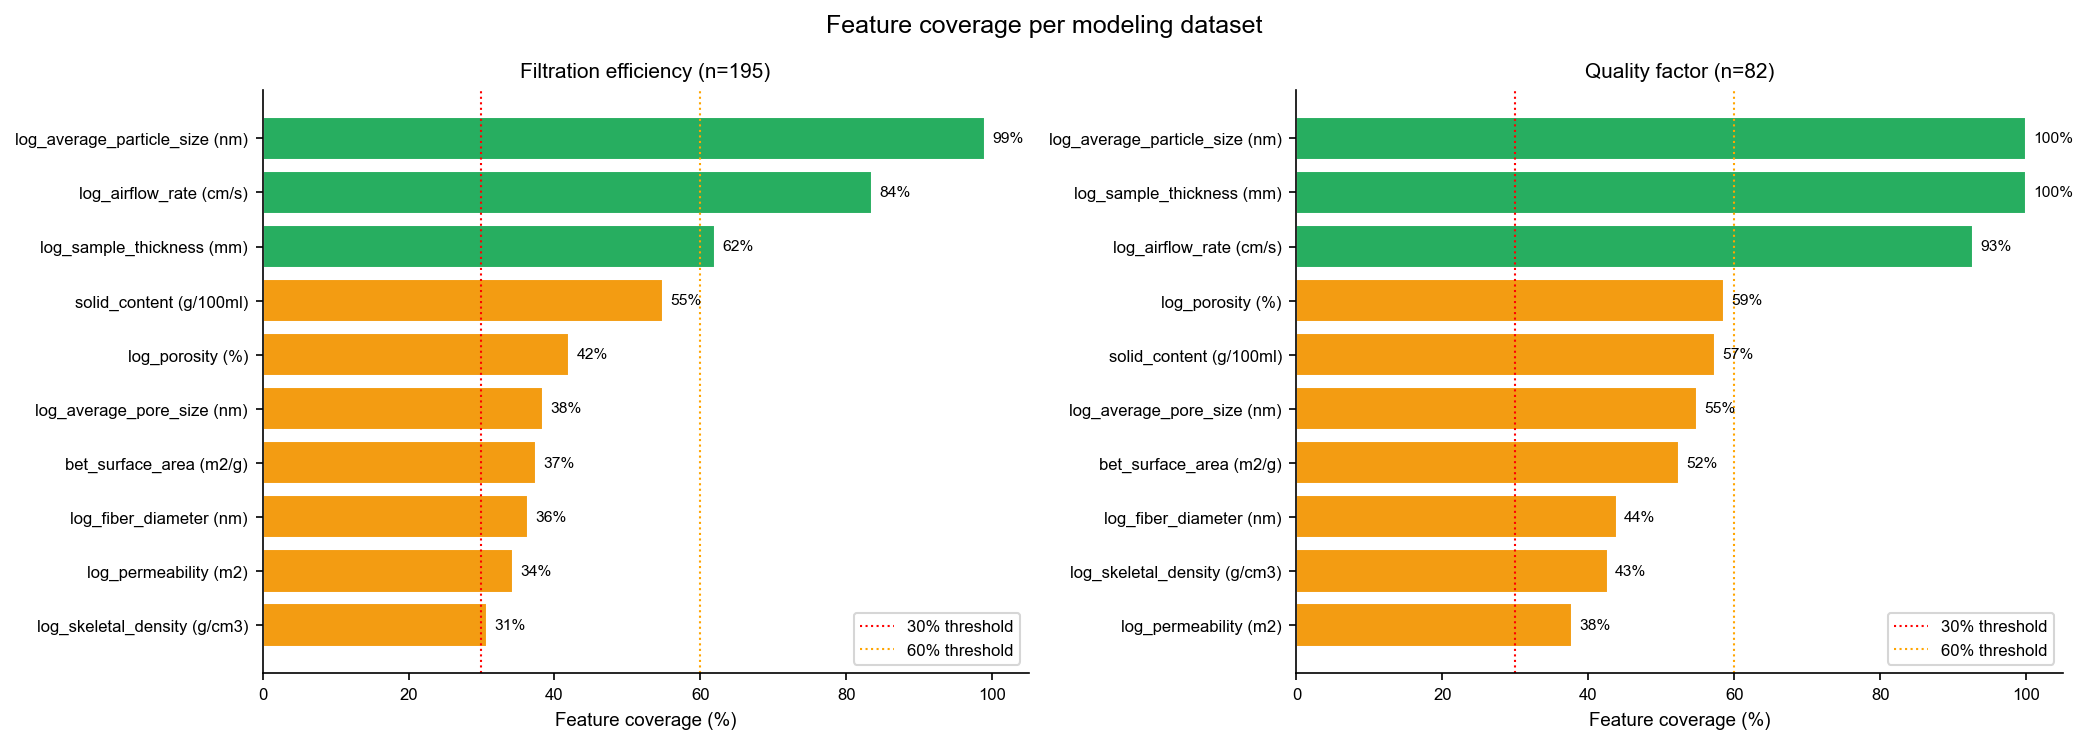

Saved: feature_coverage.png


In [23]:
# Showing which features are available vs missing in each final dataset.

numeric_feats_only = [f for f in features_available
                      if f in NUMERIC_FEATURES_FINAL and f in df_filtration.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset, name in [
    (axes[0], df_filtration,    'Filtration efficiency (n=195)'),
    (axes[1], df_qualityfactor, 'Quality factor (n=82)'),
]:
    coverage = {
        f: dataset[f].notna().sum() / len(dataset) * 100
        for f in numeric_feats_only if f in dataset.columns
    }
    features_sorted = sorted(coverage, key=coverage.get)
    values = [coverage[f] for f in features_sorted]
    colors = ['#e74c3c' if v < 30 else '#f39c12' if v < 60 else '#27ae60'
              for v in values]

    bars = ax.barh(features_sorted, values, color=colors, edgecolor='white')
    ax.axvline(30, color='red',    linestyle=':', linewidth=1, label='30% threshold')
    ax.axvline(60, color='orange', linestyle=':', linewidth=1, label='60% threshold')
    ax.set_xlim(0, 105)
    ax.set_xlabel('Feature coverage (%)')
    ax.set_title(name)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}%', va='center', fontsize=7.5)

plt.suptitle('Feature coverage per modeling dataset', fontsize=12)
plt.tight_layout()
plt.savefig('feature_coverage.png', bbox_inches='tight')
plt.show()
print('Saved: feature_coverage.png')

## 2.11: Save preprocessed datasets

In [24]:
# saving the two model-ready datasets.
# These are what Step 3 (baseline RF) and all subsequent steps will load.

df_filtration.to_csv('model_data_filtration.csv', index=False)
df_qualityfactor.to_csv('model_data_qualityfactor.csv', index=False)

print('Saved:')
print(f'  model_data_filtration.csv   — {df_filtration.shape[0]} rows x {df_filtration.shape[1]} cols')
print(f'  model_data_qualityfactor.csv — {df_qualityfactor.shape[0]} rows x {df_qualityfactor.shape[1]} cols')
print()
print('Features saved:', features_available)

# Also saving the feature list to a text file — useful for reproducibility
with open('feature_list.txt', 'w') as f:
    f.write('# Features used in ML models\n')
    f.write('# Generated by step2_preprocessing.ipynb\n\n')
    f.write('NUMERIC_FEATURES:\n')
    for feat in NUMERIC_FEATURES_FINAL:
        f.write(f'  {feat}\n')
    f.write('\nBINARY_FEATURES:\n')
    for feat in BINARY_FEATURES:
        f.write(f'  {feat}\n')
    f.write('\nDUMMY_FEATURES:\n')
    for feat in DUMMY_FEATURES:
        f.write(f'  {feat}\n')
print('Saved: feature_list.txt')

Saved:
  model_data_filtration.csv   — 195 rows x 60 cols
  model_data_qualityfactor.csv — 82 rows x 60 cols

Features saved: ['solid_content (g/100ml)', 'log_skeletal_density (g/cm3)', 'log_porosity (%)', 'log_permeability (m2)', 'bet_surface_area (m2/g)', 'log_average_pore_size (nm)', 'log_fiber_diameter (nm)', 'log_airflow_rate (cm/s)', 'log_sample_thickness (mm)', 'log_average_particle_size (nm)', 'contains_synthetic_polymer', 'contains_inorganic', 'contains_carbonaceous', 'contains_polysaccharide', 'contains_protein', 'contains_fluoropolymer', 'contains_silica', 'contains_mof', 'contains_silver', 'contains_antimicrobial_additive', 'contains_support_substrate', 'is_commercial_reference', 'architecture_descriptor_composite_filter', 'architecture_descriptor_electrospun_nanofiber_membrane', 'architecture_descriptor_fabric_supported_coating', 'architecture_descriptor_fibrous_aerogel', 'architecture_descriptor_monolithic_aerogel', 'architecture_descriptor_multilayer_filter', 'architectu

## 2.12: Step 2 checklist

In [25]:
import os

print('STEP 2 CHECKLIST')
print('=' * 55)

checks = [
    ('bulk_density dropped (collinear)',
     'bulk_density (g/cm3)' not in df_filtration.columns),

    ('permeability log-transformed',
     any('permeability' in c for c in df_filtration.columns
         if c.startswith('log_'))),

    ('Target 1 transformed (log_penetration)',
     'log_penetration' in df_filtration.columns),

    ('Target 2 transformed (log_quality_factor)',
     'log_quality_factor' in df_qualityfactor.columns),

    ('Categorical columns encoded',
     len(DUMMY_FEATURES) > 0),

    ('model_data_filtration.csv saved',
     os.path.exists('model_data_filtration.csv')),

    ('model_data_qualityfactor.csv saved',
     os.path.exists('model_data_qualityfactor.csv')),
]

all_pass = True
for label, passed in checks:
    status = 'PASS' if passed else 'FAIL'
    if not passed:
        all_pass = False
    print(f'  [{status}] {label}')

print()
if all_pass:
    print('All checks passed. Proceed to Step 3 — Baseline Random Forest.')
else:
    print('Some checks failed. Review the cells above before continuing.')

STEP 2 CHECKLIST
  [PASS] bulk_density dropped (collinear)
  [PASS] permeability log-transformed
  [PASS] Target 1 transformed (log_penetration)
  [PASS] Target 2 transformed (log_quality_factor)
  [PASS] Categorical columns encoded
  [PASS] model_data_filtration.csv saved
  [PASS] model_data_qualityfactor.csv saved

All checks passed. Proceed to Step 3 — Baseline Random Forest.


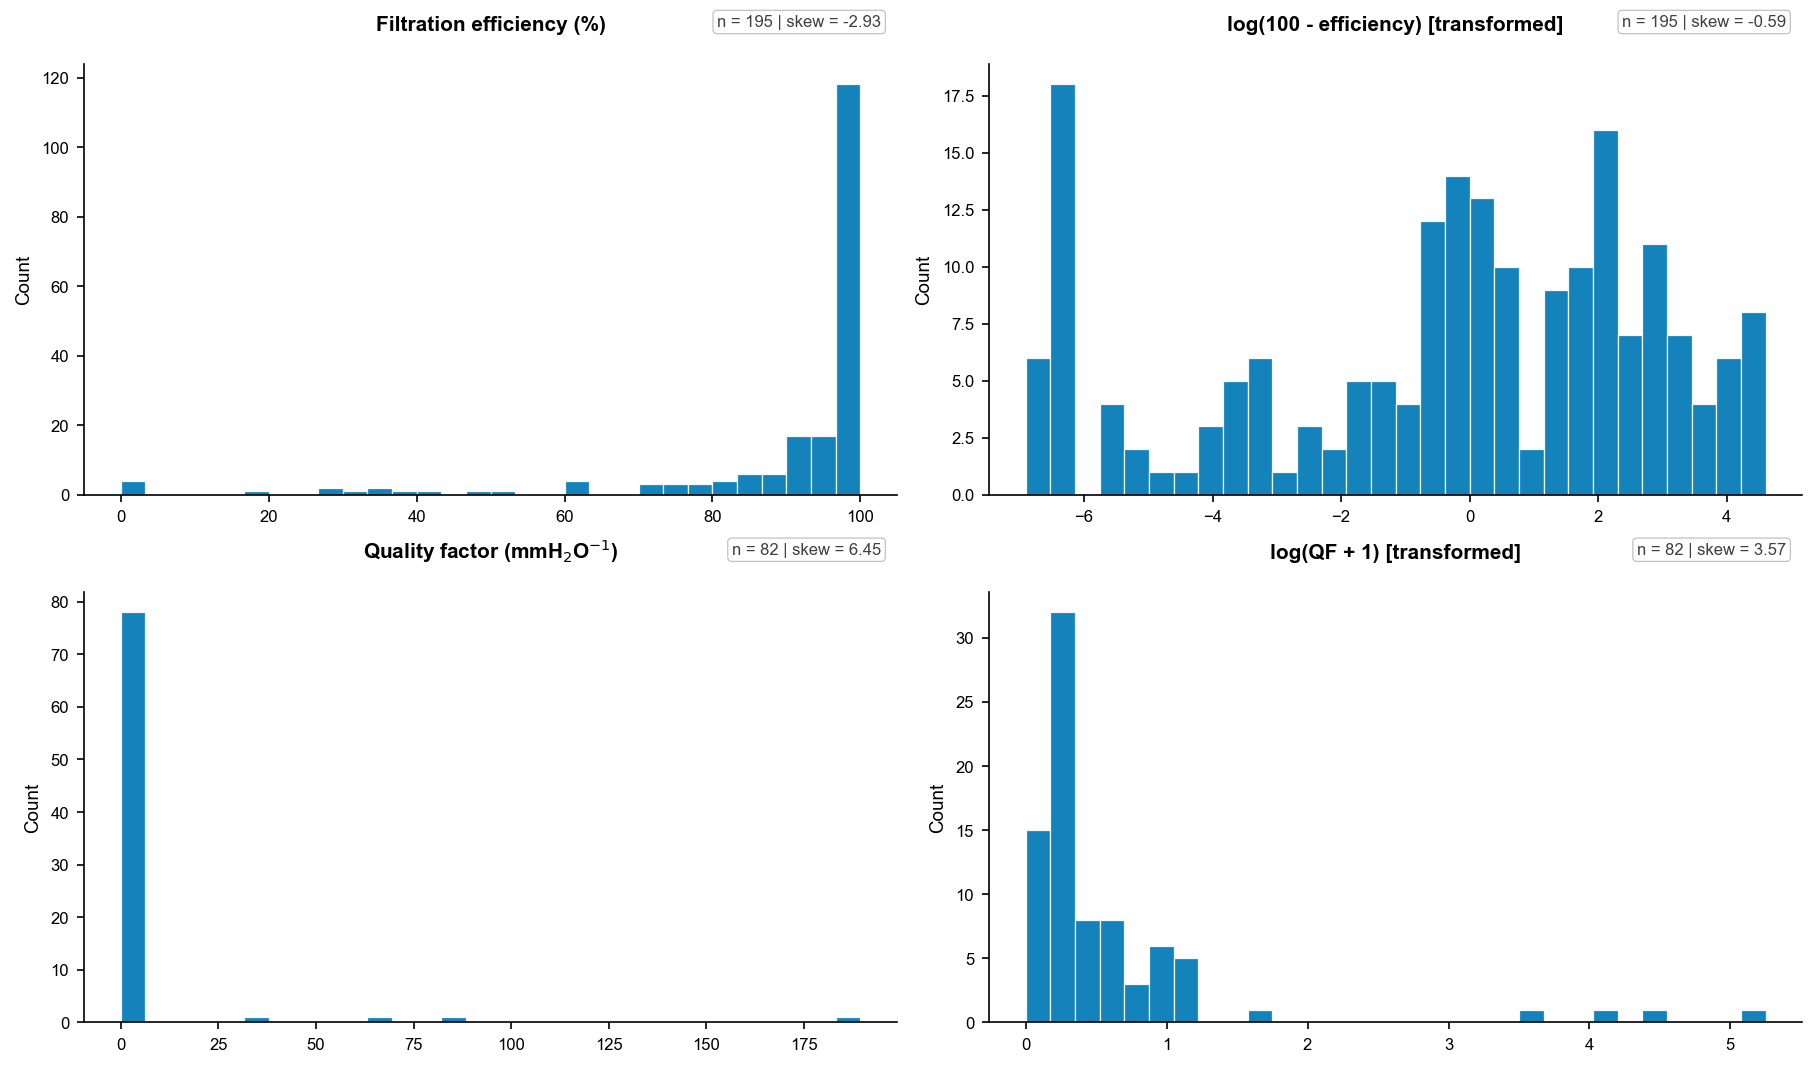

Saved: target_transform_comparison_ml_teal.png
Saved: target_transform_comparison_ml_teal.pdf


In [26]:
# Additional figure
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

bar_color = "#0077B6"   

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
fig.patch.set_facecolor("white")

pairs = [
    (TARGET_EFF,           "Filtration efficiency (%)",            axes[0, 0]),
    ("log_penetration",    "log(100 - efficiency) [transformed]",  axes[0, 1]),
    (TARGET_QF,            r"Quality factor (mmH$_2$O$^{-1}$)",    axes[1, 0]),
    ("log_quality_factor", "log(QF + 1) [transformed]",            axes[1, 1]),
]

for col, label, ax in pairs:
    if col not in df.columns:
        ax.set_visible(False)
        continue

    data = df[col].dropna().astype(float)
    data = data[np.isfinite(data)]

    if len(data) == 0:
        ax.set_visible(False)
        continue

    skew = data.skew()
    ax.set_facecolor("white")

    ax.hist(
        data,
        bins=30,
        color=bar_color,
        edgecolor="white",
        linewidth=0.6,
        alpha=0.92
    )

    ax.set_title(label, fontweight="bold", pad=16)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

    ax.text(
        0.98, 1.08,
        f"n = {len(data)} | skew = {skew:.2f}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color="0.25",
        clip_on=False,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="0.75",
            linewidth=0.6,
            alpha=0.95
        )
    )

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.savefig(
    "target_transform_comparison_ml_teal.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    "target_transform_comparison_2.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved: target_transform_comparison_ml_teal.png")
print("Saved: target_transform_comparison_ml_teal.pdf")